In [69]:
import pandas as pd


In [70]:
df=pd.read_csv(r'C:\Users\Lenovo\OneDrive\Desktop\practice\Polynomial_data.csv')
df.head()

,Temperature (C),Pressure (kPa),Unnamed: 2,Unnamed: 3,Extra Column
0,23.5,101.2,NaN,NaN,NaN
1,25.1,103.5,NaN,NaN,junk_data
2,NaN,105.8,NaN,NaN,NaN
3,27.3,NaN,NaN,NaN,NaN
4,28.9,110.2,NaN,NaN,NaN


In [71]:
df.shape

(1060, 5)

In [72]:
df.columns

Index(['Temperature (C)', 'Pressure (kPa)', 'Unnamed: 2', 'Unnamed: 3',
       'Extra Column'],
      dtype='object')

In [73]:
df=df.drop(columns=['Unnamed: 2','Unnamed: 3','Extra Column'],errors='ignore')

df.head()

,Temperature (C),Pressure (kPa)
0,23.5,101.2
1,25.1,103.5
2,NaN,105.8
3,27.3,NaN
4,28.9,110.2


In [74]:
df=df.rename(columns={'Temperature (C)':'Temperature','Pressure (kPa)':"Pressure"})

In [75]:
df['Temperature']=pd.to_numeric(df['Temperature'],errors='coerce')
df['Pressure']=pd.to_numeric(df['Pressure'],errors='coerce')



In [76]:
df.shape

(1060, 2)

In [77]:
df.isnull().sum()

Temperature     3
Pressure       12
dtype: int64

In [78]:
df.head()

,Temperature,Pressure
0,23.5,101.2
1,25.1,103.5
2,NaN,105.8
3,27.3,NaN
4,28.9,110.2


In [79]:
df['Temperature']=df['Temperature'].interpolate(method='linear')
df['Pressure']=df['Pressure'].interpolate(method='linear')

In [80]:
df.shape

(1060, 2)

In [81]:
df.head()

,Temperature,Pressure
0,23.5,101.2
1,25.1,103.5
2,26.2,105.8
3,27.3,108.0
4,28.9,110.2


In [66]:
df.dropna(inplace=True)
df.head()

,Temperature,Pressure
0,23.5,101.2
1,25.1,103.5
2,26.2,105.8
3,27.3,108.0
4,28.9,110.2


In [67]:
df.shape

(1060, 2)

In [49]:
df.isnull().sum()

Temperature    0
Pressure       0
dtype: int64

In [50]:
df.reset_index(drop=True)

,Temperature,Pressure
0,23.5,101.2
1,25.1,103.5
2,26.2,105.8
3,27.3,108.0
4,28.9,110.2
...,...,...
1055,81.4,268.9
1056,82.4,273.6
1057,83.4,278.4
1058,84.4,283.2


In [51]:
df.head()

,Temperature,Pressure
0,23.5,101.2
1,25.1,103.5
2,26.2,105.8
3,27.3,108.0
4,28.9,110.2


In [53]:
df.info

<bound method DataFrame.info of       Temperature  Pressure
0            23.5     101.2
1            25.1     103.5
2            26.2     105.8
3            27.3     108.0
4            28.9     110.2
...           ...       ...
1055         81.4     268.9
1056         82.4     273.6
1057         83.4     278.4
1058         84.4     283.2
1059         85.4     288.1

[1060 rows x 2 columns]>

In [52]:
df.describe()

,Temperature,Pressure
count,1060.000000,1060.000000
mean,56.581651,182.678585
std,18.818807,54.894939
min,21.500000,99.300000
25%,40.750000,134.075000
50%,57.800000,177.050000
75%,72.800000,228.625000
max,99.800000,288.700000


In [83]:
import matplotlib.pyplot as plt


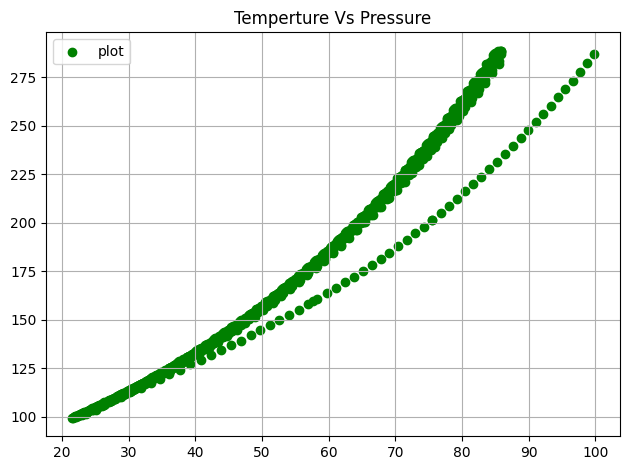

In [85]:
plt.scatter(x=df['Temperature'],y=df['Pressure'],marker='o',label='plot',c='green')

plt.title('Temperture Vs Pressure')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [87]:
x=df[['Temperature']].values
y=df[['Pressure']].values


In [88]:
x

array([[23.5],
       [25.1],
       [26.2],
       ...,
       [83.4],
       [84.4],
       [85.4]], shape=(1060, 1))

In [89]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()


In [90]:
from sklearn.metrics import r2_score

In [ ]:
#linear
deg1=lr.fit(x,y)
y_pred=deg1.predict(x)
r2_score(y,y_pred)

0.9640077393047439

In [ ]:
# ploynomial with 2 nd degree
from sklearn.preprocessing import PolynomialFeatures
py=PolynomialFeatures(degree=2)
x_poly=py.fit_transform(x)
deg2=deg1.fit(x_poly,y)
y_pred2=deg2.predict(x_poly)
r2_score(y,y_pred2)


0.9771715755501065

In [130]:
# ploynomial with 3 nd degree
pr=PolynomialFeatures(degree=3)
x_poly=pr.fit_transform(x)
deg3=deg1.fit(x_poly,y)
y_pred3=deg3.predict(x_poly)
r2_score(y,y_pred3)

0.9798544575156729

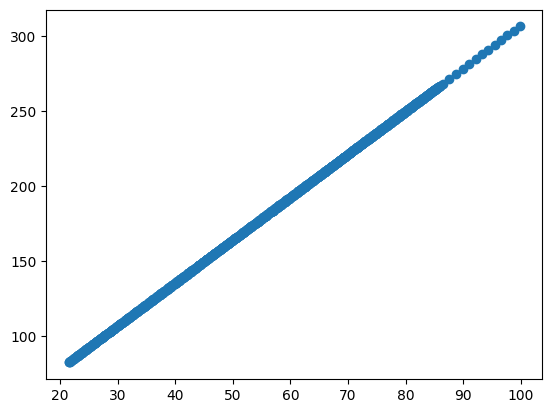

In [123]:
plt.scatter(x=df['Temperature'],y=y_pred)

In [124]:
import numpy as np

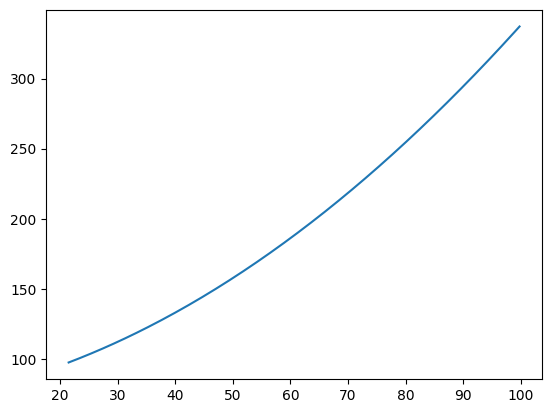

In [135]:
# Create polynomial transformer
py = PolynomialFeatures(degree=2)
x_poly = py.fit_transform(x)

# Train model
deg1 = LinearRegression()
deg1.fit(x_poly, y)

# Smooth curve
x_grid = np.linspace(min(x), max(x), 200).reshape(-1,1)
x_grid_poly = py.transform(x_grid)   # SAME py object
y_grid_pred = deg1.predict(x_grid_poly)

# Plot

plt.plot(x_grid, y_grid_pred)
plt.show()

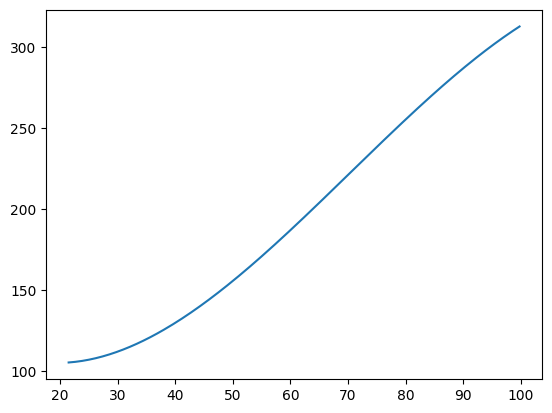

In [137]:
# Create polynomial transformer
py = PolynomialFeatures(degree=3)
x_poly = py.fit_transform(x)

# Train model
deg1 = LinearRegression()
deg1.fit(x_poly, y)

# Smooth curve
x_grid = np.linspace(min(x), max(x), 200).reshape(-1,1)
x_grid_poly = py.transform(x_grid)   # SAME py object
y_grid_pred = deg1.predict(x_grid_poly)

# Plot

plt.plot(x_grid, y_grid_pred)
plt.show()